<a href="https://colab.research.google.com/github/Arnav111garg/Basic_Quant-ML_projects/blob/main/DecisionTree.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### ***DECISION TREE***


**A decision tree is a supervised learning algorithm used for both classification and regression tasks. It has a hierarchical tree structure which consists of a root node, branches, internal nodes and leaf nodes. It works like a flowchart that helps in making step-by-step decisions, where:**

- **Internal nodes represent attribute tests**

- **Branches represent attribute values**

- **Leaf nodes represent final decisions or predictions.**


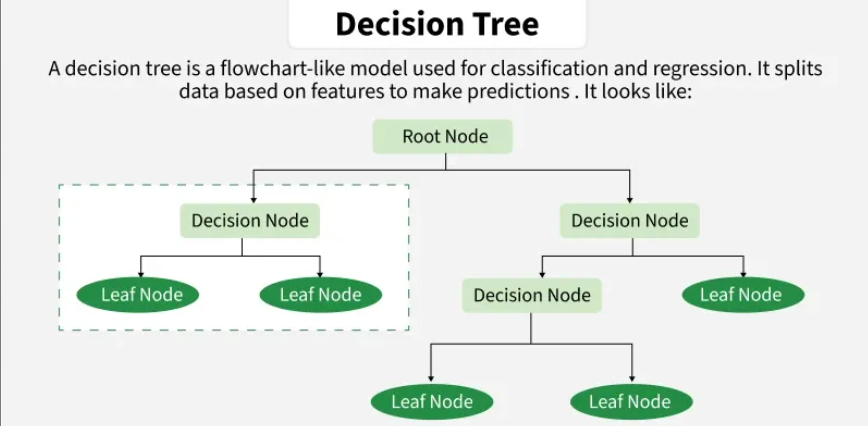

### ***Information Gain and Gini Index in Decision Tree***

1. ***Information Gain:***

   **Information Gain tells us how useful a question (or feature) is for splitting data into groups. It measures how much the uncertainty decreases after the split. A good question will create clearer groups and the feature with the highest Information Gain is chosen to make the decision.**

   - **Suppose S is a set of instances A is an attribute, Sᵥ is the subset of S, v represents an individual value that the attribute A can take and Values (A) is the set of all possible values of A.**
   - **Entropy: It is the measure of uncertainty of a random variable, it characterizes the impurity of an arbitrary collection of examples. The higher the entropy more the information content.**


- Suppose S is a set of instances, A is an attribute, Sᵥ is the subset of S with A = v and Values (A) is the set of all possible values of A.


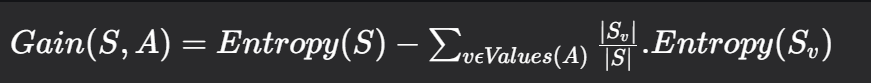


### ***Building Decision Tree using Information Gain the essentials:***

- **Start with all training instances associated with the root node**

- **Use info gain to choose which attribute to label each node**

- **Recursively construct each subtree on the subset of training instances that would be classified down that path in the tree.**

- **If all positive or all negative training instances remain, the label that node “yes" or “no" accordingly**

- **If no attributes remain label with a majority vote of training instances left at that node**

- **If no instances remain label with a majority vote of the parent's training instances.**

###  ***2. Gini Index***


**Gini Index is a metric to measure how often a randomly chosen element would be incorrectly identified. It means an attribute with a lower Gini index should be preferred. Sklearn supports “Gini” criteria for Gini Index and by default it takes “gini” value.**


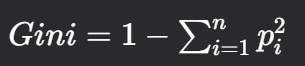

### ***Some additional features of the Gini Index are:***

- **It is calculated by summing the squared probabilities of each outcome in a distribution and subtracting the result from 1.**

- **A lower Gini Index indicates a more homogeneous or pure distribution while a higher Gini Index indicates a more heterogeneous or impure distribution.**

- **Gini Index is used to evaluate the quality of a split by measuring the difference between the impurity of the parent node and the weighted impurity of the child nodes.**

- **Compared to other impurity measures like entropy, the Gini Index is faster to compute and more sensitive to changes in class probabilities.**

- **One disadvantage of the Gini Index is that it tends to favour splits that create equally sized child nodes, even if they are not optimal for classification accuracy.**

- **In practice the choice between using the Gini Index or other impurity measures depends on the specific problem and dataset and requires experimentation and tuning.**

### ***PROJECT IDEA:                                                             "Nonlinear Alpha Model for Equity Direction using Decision Trees"***


### ***CORE IDEA OF THE PROJECT***

**This project builds a Decision Tree-based model to predict the direction of stock returns using historical market features. Unlike logistic regression, the model captures nonlinear relationships and interactions between features. The output is a classification (up/down), which is converted into trading signals. The project focuses on understanding how tree-based models partition financial data into decision rules. It connects machine learning predictions to a simple trading strategy. The goal is to evaluate whether nonlinear models improve trading performance over linear ones.**

### ***Why This Project is Important***

**Financial markets often exhibit nonlinear and regime-dependent behavior, which linear models cannot capture effectively. Decision Trees introduce the concept of rule-based modeling, widely used in quant strategies. This project teaches how models can automatically discover feature interactions, such as momentum working only under certain volatility conditions. It also highlights the problem of overfitting, which is critical in financial data. Tree-based models are the foundation of more advanced methods like Random Forest and boosting. This makes the project a key step toward industry-level modeling.**

In [2]:
# Import Neccessary Libararies
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, roc_curve, roc_auc_score, precision_recall_curve, auc, recall_score, precision_score, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Downloading Data
Asset = yf.download("^NSEI", start="2015-01-01", end="2026-04-01")
Asset = pd.DataFrame(Asset)
Asset.head()

/tmp/ipykernel_16430/1782636281.py:13: FutureWarning: YF.download() has changed argument auto_adjust default to True
  Asset = yf.download("^NSEI", start="2015-01-01", end="2026-04-01")
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,^NSEI,^NSEI,^NSEI,^NSEI,^NSEI
Date,,,,,
2015-01-02,8395.450195,8410.599609,8288.700195,8288.700195,101900
2015-01-05,8378.400391,8445.599609,8363.900391,8407.950195,118200
2015-01-06,8127.350098,8327.849609,8111.350098,8325.299805,172800
2015-01-07,8102.100098,8151.200195,8065.450195,8118.649902,164100
2015-01-08,8234.599609,8243.500000,8167.299805,8191.399902,143800


In [3]:
# Creating Returns Column
Asset['Returns'] = Asset['Close'].ffill().pct_change()
Asset

Price,Close,High,Low,Open,Volume,Returns
Ticker,^NSEI,^NSEI,^NSEI,^NSEI,^NSEI,
Date,,,,,,
2015-01-02,8395.450195,8410.599609,8288.700195,8288.700195,101900,NaN
2015-01-05,8378.400391,8445.599609,8363.900391,8407.950195,118200,-0.002031
2015-01-06,8127.350098,8327.849609,8111.350098,8325.299805,172800,-0.029964
2015-01-07,8102.100098,8151.200195,8065.450195,8118.649902,164100,-0.003107
2015-01-08,8234.599609,8243.500000,8167.299805,8191.399902,143800,0.016354
...,...,...,...,...,...,...
2026-03-23,22512.650391,22851.699219,22471.250000,22824.349609,550300,-0.026038
2026-03-24,22912.400391,23057.300781,22624.199219,22878.449219,538100,0.017757


In [4]:
Asset['ret_1'] = Asset['Returns']

Asset['volatility'] = Asset['Returns'].rolling(10).std()

In [5]:
Asset['ret_5'] = Asset['Close'].pct_change(5)
Asset['ma_10'] = Asset['Close'].rolling(10).mean()
Asset['ma_20'] = Asset['Close'].rolling(20).mean()

Asset['ma_diff'] = Asset['ma_10'] - Asset['ma_20']

In [6]:
# Creating Target Variable
Asset['future_return'] = Asset['Returns'].shift(-1)

Asset['target'] = (Asset['future_return'] > 0).astype(int)

Asset = Asset.dropna()

In [7]:
split = int(len(Asset) * 0.7)

train = Asset.iloc[:split]
test = Asset.iloc[split:]

In [8]:
features = ['ret_1', 'ret_5', 'ma_diff', 'volatility']

X_train = train[features].values
y_train = train['target'].values

X_test = test[features].values
y_test = test['target'].values

In [13]:
class DecisionTree:

    def __init__(self, max_depth=3):
        self.max_depth = max_depth

    def gini(self, y):
        p = np.mean(y)
        return 1 - (p**2 + (1 - p)**2)

    def split(self, X, y, feature, threshold):
        left_mask = X[:, feature] <= threshold
        right_mask = X[:, feature] > threshold

        return X[left_mask], y[left_mask], X[right_mask], y[right_mask]

    def best_split(self, X, y):

        best_feature, best_thresh = None, None
        best_impurity = 1e9

        for feature in range(X.shape[1]):
            thresholds = np.unique(X[:, feature])

            for t in thresholds:

                _, y_left, _, y_right = self.split(X, y, feature, t)

                if len(y_left) == 0 or len(y_right) == 0:
                    continue

                impurity = (len(y_left) * self.gini(y_left) +
                    len(y_right) * self.gini(y_right)) / len(y)

                if impurity < best_impurity:
                    best_impurity = impurity
                    best_feature = feature
                    best_thresh = t

        return best_feature, best_thresh

    def build_tree(self, X, y, depth=0):

        if depth >= self.max_depth or len(np.unique(y)) == 1:
            return np.mean(y)

        feature, thresh = self.best_split(X, y)

        if feature is None:
            return np.mean(y)

        X_l, y_l, X_r, y_r = self.split(X, y, feature, thresh)

        return {
            'feature': feature,
            'threshold': thresh,
            'left': self.build_tree(X_l, y_l, depth+1),
            'right': self.build_tree(X_r, y_r, depth+1)}

    def fit(self, X, y):
        self.tree = self.build_tree(X, y)

    def predict_one(self, x, tree):

        if not isinstance(tree, dict):
            return tree

        if x[tree['feature']] <= tree['threshold']:
            return self.predict_one(x, tree['left'])
        else:
            return self.predict_one(x, tree['right'])

    def predict(self, X):
        return np.array([self.predict_one(x, self.tree) for x in X])

model = DecisionTree(max_depth=3)
model.fit(X_train, y_train)

In [14]:
probs = model.predict(X_test)  # values between 0 and 1

In [15]:
signals = np.zeros_like(probs)

signals[probs > 0.55] = 1
signals[probs < 0.45] = -1

In [16]:
returns = test['future_return'].values
strategy_returns = signals * returns

In [17]:
preds = (probs > 0.5).astype(int)
def sharpe(r):
    return np.mean(r) / np.std(r) * np.sqrt(252)

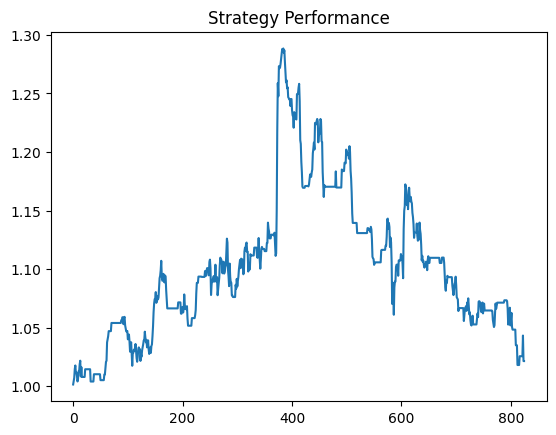

In [18]:
cum_returns = (1 + strategy_returns).cumprod()

plt.plot(cum_returns)
plt.title("Strategy Performance")
plt.show()